In [2]:
import pandas as pd
df=pd.read_csv("bostonhouse.csv")

In [3]:
# Step 3: Column names from original Boston dataset
feature_names = [
    'CRIM',    # per capita crime rate by town
    'ZN',      # proportion of residential land zoned for lots over 25,000 sq.ft.
    'INDUS',   # proportion of non-retail business acres per town
    'CHAS',    # Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
    'NOX',     # nitric oxides concentration (parts per 10 million)
    'RM',      # average number of rooms per dwelling
    'AGE',     # proportion of owner-occupied units built prior to 1940
    'DIS',     # weighted distances to five Boston employment centres
    'RAD',     # index of accessibility to radial highways
    'TAX',     # full-value property-tax rate per $10,000
    'PTRATIO', # pupil-teacher ratio by town
    'B',       # 1000(Bk - 0.63)^2 where Bk is the proportion of Black people
    'LSTAT'    # % lower status of the population
]

In [4]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [5]:
#import seaborn as sns
#sns.pairplot(df)

In [6]:
#df.isnull().sum()

In [7]:
#df.info()

In [8]:
df.rename(columns={'MEDV':'Price'},inplace=True)
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


<Axes: >

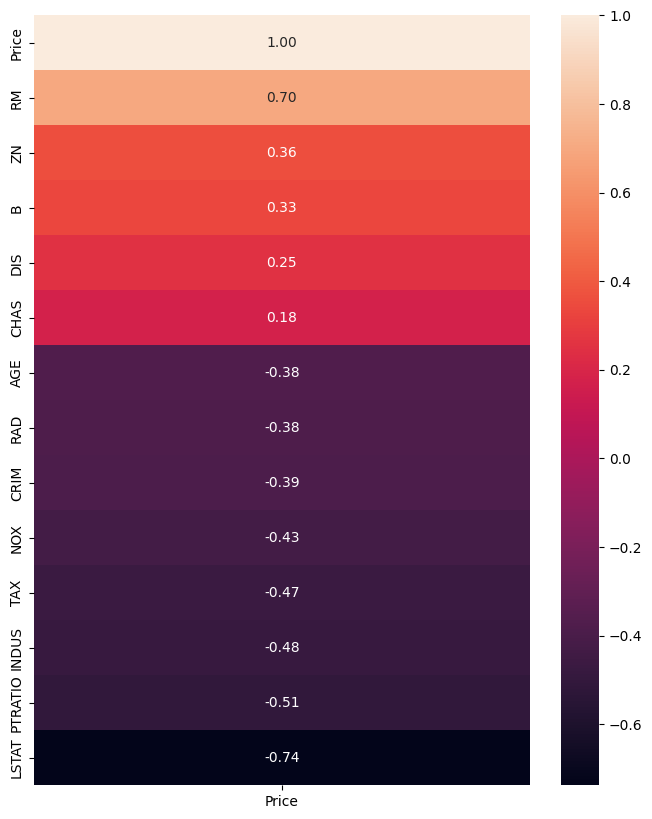

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
corr=df.corr()[['Price']].sort_values(by='Price',ascending=False)

#plot
plt.figure(figsize=(8,10))
sns.heatmap(corr,annot=True,fmt='.2f')

In [10]:
df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'Price'],
      dtype='str')

In [11]:
#feature engineering

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X=df.iloc[:,:-1]

In [14]:
y=df.iloc[:,-1]

In [15]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=20)

In [16]:
X_train.shape,X_test.shape

((379, 13), (127, 13))

In [17]:
y_train.shape,y_test.shape

((379,), (127,))

In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
scaler=StandardScaler()

In [20]:
X_train=scaler.fit_transform(X_train)

In [21]:
#X_train

In [22]:
from sklearn.linear_model import LinearRegression

In [23]:
model=LinearRegression()

In [24]:
#traning
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[-0.48, 0.81, 0.24,...,-1.84, 0.89,-3.55]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,22.73
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,13
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](13,)","[48.39,24.23,21.53,..., 8.36, 7.86, 5.06]"


In [25]:
#train acc
model.score(X_train,y_train)

0.7419182949166911

In [26]:
X_test=scaler.transform(X_test)

In [27]:
y_pred=model.predict(X_test)

In [28]:
X_test

array([[-0.40569497, -0.51267731, -0.22436988, ...,  0.37099595,
         0.45151019,  0.04620631],
       [-0.42948744,  0.68396442,  0.54087139, ..., -0.09305509,
         0.45151019, -0.27427283],
       [-0.23378477, -0.51267731,  1.1902537 , ..., -1.71723374,
         0.18947332,  0.20850905],
       ...,
       [-0.41638448, -0.51267731, -0.17859844, ..., -0.27867551,
         0.42552396, -0.3141608 ],
       [ 0.76897826, -0.51267731,  0.97856079, ...,  0.83504699,
         0.3603953 ,  0.53036364],
       [ 0.15935485, -0.51267731,  0.97856079, ...,  0.83504699,
         0.21904761, -1.28247546]], shape=(127, 13))

In [29]:
y_pred[1]

np.float64(27.00881766985529)

In [30]:
y_test

498    21.2
94     20.6
150    21.5
221    21.7
423    13.4
       ... 
437     8.7
195    50.0
117    19.2
447    12.6
368    50.0
Name: Price, Length: 127, dtype: float64

In [31]:
from sklearn.metrics import r2_score

In [32]:
r2_score(y_test,y_pred)

0.7185236383055428

In [33]:
y_pred_train=model.predict(X_train)

In [34]:
r2_score(y_train,y_pred_train)

0.7419182949166911

In [35]:
model.predict(scaler.transform([[0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98]]))

C:\Users\Anuja\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([29.66968193])

In [36]:
import joblib


In [37]:
joblib.dump(model,'model.joblib')

['model.joblib']

In [38]:
joblib.dump(scaler,'scaler.joblib')

['scaler.joblib']

Prediction by using joblib

In [39]:
model_joblib=joblib.load('model.joblib')

In [40]:
scaler_joblib=joblib.load('scaler.joblib')

In [41]:
#print(dir(model_joblib))

In [42]:
model_joblib.predict(scaler_joblib.transform([[0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98]]))

C:\Users\Anuja\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([29.66968193])

In [43]:
X.columns


Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT'],
      dtype='str')